# 01 — EDA: Spatial & Temporal Patterns

Exploración inicial de `Train.csv`/`Test.csv` antes de cualquier feature engineering (ver `structuring-ml-projects` workflow, paso 2). Objetivos:
- Entender patrones espaciales (componente GIS)
- Entender dinámica temporal por celda
- Rankear la señal cruda de cada feature candidata contra `target` antes de decidir qué construir

No se hace ninguna llamada de diseño aquí: solo lectura de datos ya validada en `src/`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data

train, test, sample_submission = data.load_raw_data()
print("train:", train.shape)
print("test: ", test.shape)
train.head()



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\alher\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\alher\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\alher\anaconda3\Lib\site-pac

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\alher\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\alher\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\alher\anaconda3\Lib\site-pac

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



train: (2154021, 13)
test:  (280961, 13)


,ID,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,0.5,-0.866025,0.207665
1,20020501_-55.5_-67.5,2002-05-01,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,0.5,-0.866025,0.634465
2,20020501_-54.5_-71.5,2002-05-01,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,0.5,-0.866025,-0.337083
3,20020501_-54.5_-70.5,2002-05-01,-54.5,-70.5,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,0.5,-0.866025,-0.148142
4,20020501_-54.5_-69.5,2002-05-01,-54.5,-69.5,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,0.5,-0.866025,0.089539


## Schema & masking

In [2]:
print("Train columns:", train.columns.tolist())
print("Test columns: ", test.columns.tolist())

masked_share = test[config.TWS_MASKED_COL].mean()
print(f"\nTest TWS_t masked: {masked_share:.1%}")


Train columns: ['ID', 'time', 'lat', 'lon', 'TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos', 'target']
Test columns:  ['ID', 'time', 'lat', 'lon', 'TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos', 'TWS_t_masked']

Test TWS_t masked: 66.5%


## Spatial patterns (GIS)

TWS_t y SPEI_01_t en el mismo mes: estructura geográfica (continentes húmedos/secos, océanos enmascarados por el propio dataset terrestre).

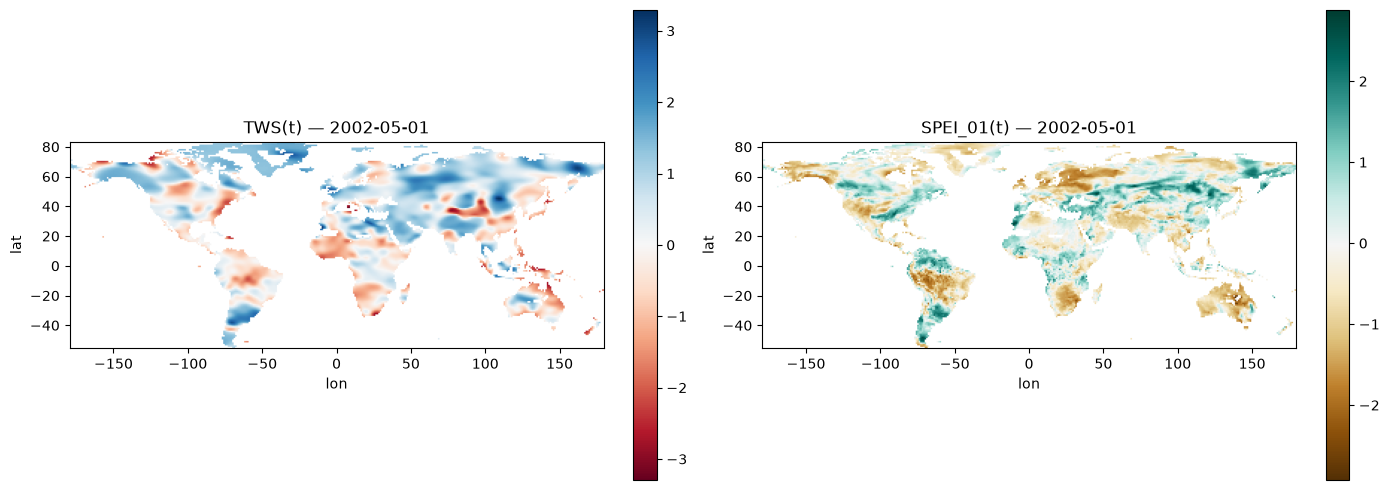

In [3]:
def pivot_grid(df, time_value, value_col):
    sub = df.loc[df[config.TIME_COL] == time_value, [config.LAT_COL, config.LON_COL, value_col]]
    return (
        sub.pivot(index=config.LAT_COL, columns=config.LON_COL, values=value_col)
        .sort_index()
        .sort_index(axis=1)
    )


t0 = train[config.TIME_COL].min()
grid_tws = pivot_grid(train, t0, config.TWS_COL)
grid_spei = pivot_grid(train, t0, "SPEI_01_t")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

im0 = axs[0].imshow(
    grid_tws.values, cmap="RdBu", origin="lower",
    extent=[grid_tws.columns.min(), grid_tws.columns.max(),
            grid_tws.index.min(), grid_tws.index.max()],
)
axs[0].set_title(f"TWS(t) — {str(t0)[:10]}")
axs[0].set_xlabel("lon"); axs[0].set_ylabel("lat")
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(
    grid_spei.values, cmap="BrBG", origin="lower",
    extent=[grid_spei.columns.min(), grid_spei.columns.max(),
            grid_spei.index.min(), grid_spei.index.max()],
)
axs[1].set_title(f"SPEI_01(t) — {str(t0)[:10]}")
axs[1].set_xlabel("lon"); axs[1].set_ylabel("lat")
plt.colorbar(im1, ax=axs[1], fraction=0.046)

plt.tight_layout()
plt.show()


## ¿Qué meses de test están enmascarados?

66.5% de `TWS_t` en test está enmascarado. Relevante para el relleno compatible con las reglas (solo histórico estrictamente anterior de esa celda — ver README «Competition constraints»).

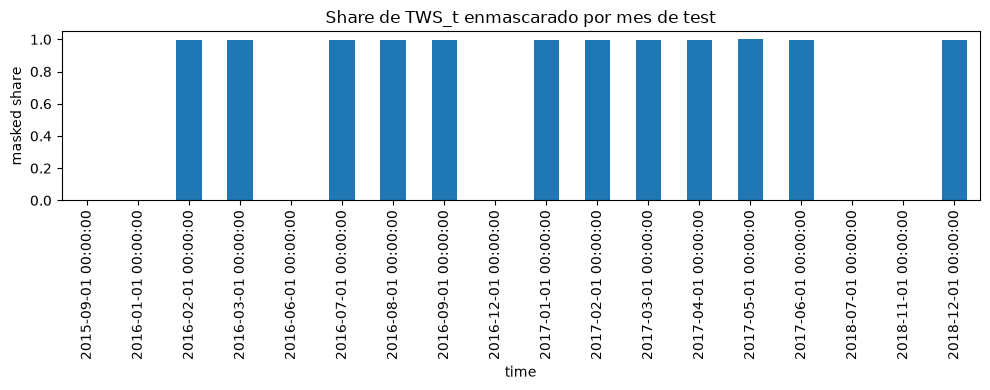

time
2015-09-01    0.000000
2016-01-01    0.000000
2016-02-01    0.997574
2016-03-01    0.998915
2016-06-01    0.000000
2016-07-01    0.995831
2016-08-01    0.997680
2016-09-01    0.996780
2016-12-01    0.000000
2017-01-01    0.998142
2017-02-01    0.996740
2017-03-01    0.997385
2017-04-01    0.998657
2017-05-01    0.999743
2017-06-01    0.997818
2018-07-01    0.000000
2018-11-01    0.000000
2018-12-01    0.998018
Name: TWS_t_masked, dtype: float64

In [4]:
masked_by_month = test.groupby(config.TIME_COL)[config.TWS_MASKED_COL].mean().sort_index()
ax = masked_by_month.plot(kind="bar", figsize=(10, 4), title="Share de TWS_t enmascarado por mes de test")
ax.set_ylabel("masked share")
plt.tight_layout()
plt.show()
masked_by_month


## Dinámica temporal en una celda de muestra

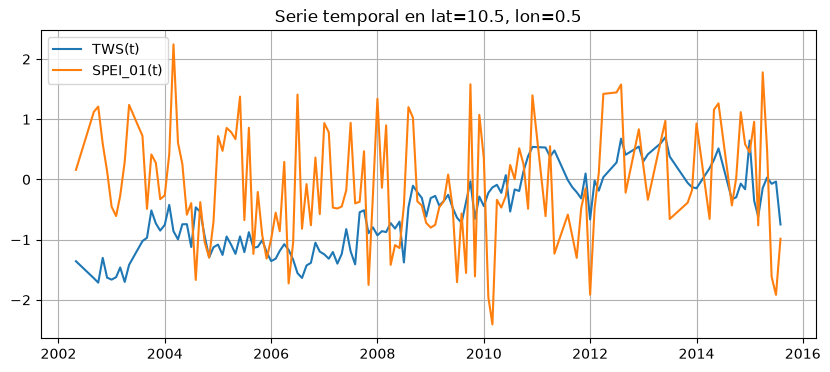

In [5]:
lat0, lon0 = 10.5, 0.5
nearest_lat = train[config.LAT_COL].sub(lat0).abs().idxmin()
nearest_lat = train.loc[nearest_lat, config.LAT_COL]
nearest_lon = train[config.LON_COL].sub(lon0).abs().idxmin()
nearest_lon = train.loc[nearest_lon, config.LON_COL]

ts = train[
    (train[config.LAT_COL] == nearest_lat) & (train[config.LON_COL] == nearest_lon)
].sort_values(config.TIME_COL)

plt.figure(figsize=(10, 4))
plt.plot(ts[config.TIME_COL], ts[config.TWS_COL], label="TWS(t)")
plt.plot(ts[config.TIME_COL], ts["SPEI_01_t"], label="SPEI_01(t)")
plt.legend(); plt.grid(True)
plt.title(f"Serie temporal en lat={nearest_lat}, lon={nearest_lon}")
plt.show()


## Ranking de señal cruda (correlación con `target`)

Paso 2 del workflow de `structuring-ml-projects`: rankear la correlación de cada feature candidata con `target` antes de decidir qué feature engineering merece la pena construir.

In [6]:
candidate_cols = [config.TWS_COL] + config.OPTIONAL_FEATURE_COLS + ["month_sin", "month_cos"]
corr = train[candidate_cols + [config.TARGET_COL]].corr()[config.TARGET_COL].drop(config.TARGET_COL)
corr.sort_values(key=abs, ascending=False)


TWS_t              0.803260
SPEI_12_t          0.379573
SPEI_06_t          0.368248
SOIL_MOISTURE_t    0.320483
SPEI_03_t          0.285371
SPEI_01_t          0.203882
month_sin         -0.016912
month_cos          0.002764
Name: target, dtype: float64

## Fuerza de la persistencia

`TWS(t+1) ≈ TWS(t)` es el benchmark que cualquier modelo debe superar (`src/model.py::make_persistence_prediction`).

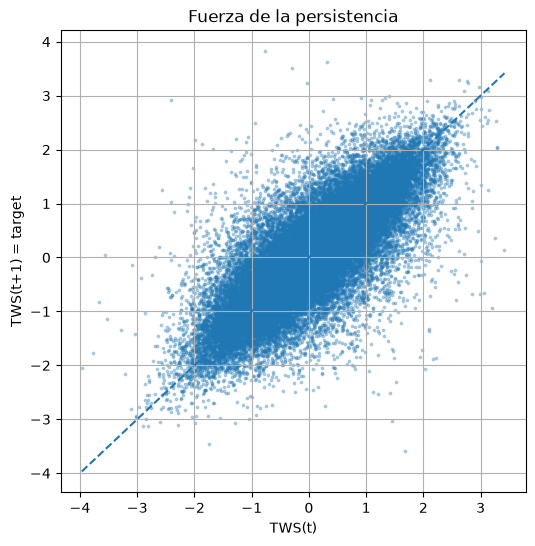

In [7]:
pairs = train[[config.TWS_COL, config.TARGET_COL]].dropna()
sample = pairs.sample(n=min(50000, len(pairs)), random_state=config.RANDOM_STATE)

plt.figure(figsize=(6, 6))
plt.scatter(sample[config.TWS_COL], sample[config.TARGET_COL], s=3, alpha=0.3)
mn, mx = sample[config.TWS_COL].min(), sample[config.TWS_COL].max()
plt.plot([mn, mx], [mn, mx], "--")
plt.xlabel("TWS(t)"); plt.ylabel("TWS(t+1) = target")
plt.title("Fuerza de la persistencia")
plt.grid(True)
plt.show()


## Hallazgos

- **`TWS_t` domina la señal cruda** (corr. 0.80 con `target`) — consistente con la fuerte persistencia mes a mes que ya usa el benchmark.
- **Los SPEI de horizonte largo aportan más que los cortos**: `SPEI_12_t` (0.38) y `SPEI_06_t` (0.37) correlacionan más con `target` que `SPEI_01_t` (0.20). La sequía/humedad acumulada de varios meses predice mejor el TWS del mes siguiente que el desvío de un solo mes.
- `SOIL_MOISTURE_t` aporta señal moderada (0.32), similar a `SPEI_03_t` (0.29).
- `month_sin`/`month_cos` casi sin correlación lineal con `target` (~0) — el target ya son anomalías, sin estacionalidad fuerte residual.
- **El enmascarado de test no es uniforme**: 6 de los 18 meses están 100% observados (2015-09, 2016-01, 2016-06, 2016-12, 2018-07, 2018-11) y los otros 12 están enmascarados en >99.5% de sus celdas. Casi todas las filas "difíciles" de test caen en esos 12 meses, donde casi no hay `TWS_t` propio disponible — el modelo dependerá casi enteramente de SPEI/soil moisture/historial de la celda ahí. Vale la pena medir el RMSE por separado en esos 12 meses vs. los 6 observados en el próximo ciclo de validación.
- El mapa espacial de `TWS_t`/`SPEI_01_t` muestra estructura geográfica clara (continentes húmedos/secos correlacionados) — apoya invertir en features de agregación espacial de vecinos (permitidas por las reglas del reto, ver README) como siguiente paso de feature engineering.